# 02 — İlk Ay Enrichment Keşfi
Claude'un Temmuz 2025 review'larından ne çıkardığını inceleyelim.

In [11]:
import os, sys

# .env ve app/ backend klasöründe — oraya geç
os.chdir(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'backend'))
sys.path.insert(0, '.')

import asyncio
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text
from app.api.deps import AsyncSessionLocal

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 50)
print('Hazır. Çalışma dizini:', os.getcwd())

Hazır. Çalışma dizini: c:\Users\Eren\Desktop\vs code\review-radar\backend


## 1. Reviews tablosu — Claude'un ürettikleri

In [12]:
async def query(sql):
    async with AsyncSessionLocal() as db:
        r = await db.execute(text(sql))
        return r.fetchall(), r.keys()

rows, keys = await query("""
    SELECT review_id, date, rating, company_size,
           topics, sentiment, summary
    FROM reviews
    ORDER BY date
""")

df = pd.DataFrame(rows, columns=list(keys))
print(f'Toplam işlenmiş review: {len(df)}')
df.head(10)

Toplam işlenmiş review: 32


,review_id,date,rating,company_size,topics,sentiment,summary
0,11431494,2025-07-24,5.0,Small-Business (50 or fewer emp.),"[veri kalitesi, genel olumlu]",pozitif,"Apollo.io satış deneyimi ve yüksek kaliteli leads sayesinde başarılı prospecting sonuçları sağlamakla birlikte, kull..."
1,11428282,2025-07-25,4.5,Enterprise (> 1000 emp.),"[otomasyon, email deliverability, genel olumlu]",pozitif,"Apollo.io prospecting ve email sequencing özellikleri ile arama imkanı sunsa da, bazı MEA ülkelerinde çağrı kopması ..."
2,11438286,2025-07-26,4.0,Small-Business (50 or fewer emp.),"[veri kalitesi, arama & filtreleme, UX / kullanım kolaylığı, entegrasyon, otomasyon, genel olumlu]",pozitif,Apollo.io geniş B2B veri tabanı ve LinkedIn entegrasyonu ile hızlı prospecting sağlıyor ancak veri doğruluğu düşük v...
3,11439466,2025-07-27,5.0,NaN,"[arama & filtreleme, UX / kullanım kolaylığı, genel olumlu]",pozitif,"Apollo.io, lead ve e-posta alma işlemini çok kolaylaştırıyor ancak web sitesi tasarımında iyileştirme gerektiriyor."
4,11443191,2025-07-28,4.5,Small-Business (50 or fewer emp.),"[UX / kullanım kolaylığı, entegrasyon]",pozitif,Apollo.io kullanım açısından kolay olsa da NetHunt ve Microsoft Dynamics gibi bazı CRM sistemleriyle entegrasyon eks...
5,11443228,2025-07-28,4.0,NaN,"[UX / kullanım kolaylığı, müşteri desteği, genel olumlu]",pozitif,"Kullanıcı Apollo'nun kullanımı kolay arayüzü, geniş araç ve bilgi yelpazesi ile her gün sorunsuz şekilde kullandığın..."
6,11442580,2025-07-28,5.0,Small-Business (50 or fewer emp.),"[UX / kullanım kolaylığı, fiyat, genel olumlu]",pozitif,"Apollo.io kullanıcı dostu arayüzü ve şeffaf fiyatlandırmasından memnun olup, veri tamlığı dışında ciddi bir sorunu b..."
7,11445379,2025-07-28,5.0,Small-Business (50 or fewer emp.),"[veri kalitesi, UX / kullanım kolaylığı, genel olumlu]",pozitif,"Kullanıcı Apollo'nun LinkedIn'den lead çekme, veri kalitesi ve kolay kullanım arayüzü sayesinde 8-9 ay boyunca B2B s..."
8,11443155,2025-07-28,5.0,Mid-Market (51-1000 emp.),"[veri kalitesi, email deliverability, entegrasyon, otomasyon, UX / kullanım kolaylığı, genel olumlu]",pozitif,"Apollo.io, doğru iletişim verileri, entegrasyon yetenekleri ve otomasyon özellikleriyle prospecting sürecini önemli ..."
9,11441106,2025-07-28,5.0,Mid-Market (51-1000 emp.),"[veri kalitesi, arama & filtreleme]",pozitif,"Apollo.io'da ihtiyaç duyulan bilgileri düzenli olarak bulabilmek mümkün olsa da, cep telefonu numarası seçeneği sını..."


## 2. Sentiment dağılımı

sentiment
pozitif    29
negatif     2
nötr        1
Name: count, dtype: int64


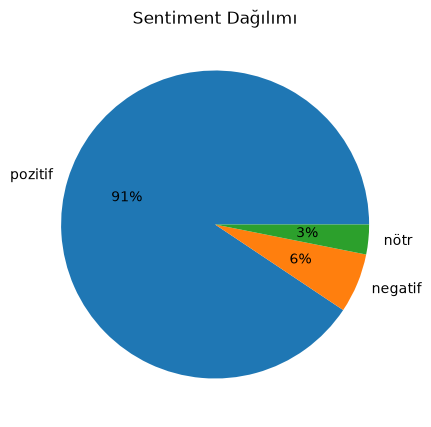

In [13]:
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

sentiment_counts.plot.pie(autopct='%1.0f%%', figsize=(5,5), title='Sentiment Dağılımı')
plt.ylabel('')
plt.show()

## 3. Konu etiketi dağılımı

genel olumlu               19
UX / kullanım kolaylığı    19
veri kalitesi              16
arama & filtreleme         14
otomasyon                  11
entegrasyon                 7
email deliverability        6
fiyat                       6
müşteri desteği             4
raporlama & analitik        1
dtype: int64


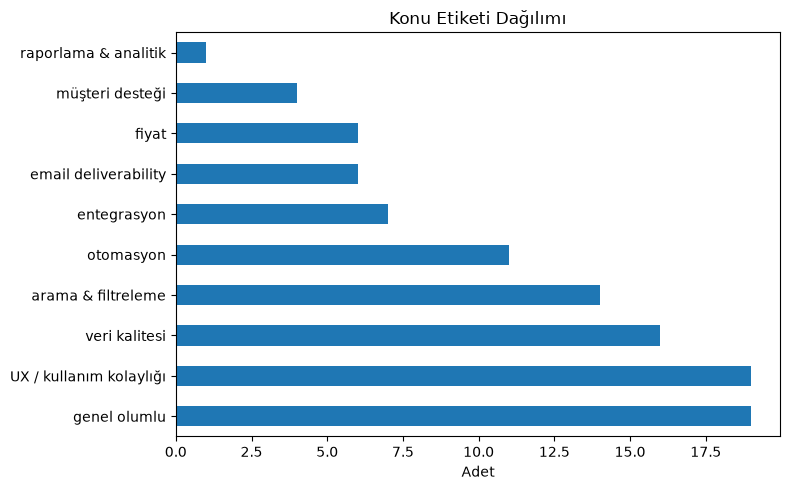

In [14]:
from collections import Counter

all_topics = [t for topics in df['topics'] for t in (topics or [])]
topic_counts = pd.Series(Counter(all_topics)).sort_values(ascending=False)
print(topic_counts)

topic_counts.plot.barh(figsize=(8,5), title='Konu Etiketi Dağılımı')
plt.xlabel('Adet')
plt.tight_layout()
plt.show()

## 4. Konu × Sentiment çapraz tablosu

In [15]:
rows2, keys2 = await query("""
    SELECT topic, sentiment, SUM(count) as total
    FROM review_aggregates
    GROUP BY topic, sentiment
    ORDER BY total DESC
""")

agg = pd.DataFrame(rows2, columns=list(keys2))
pivot = agg.pivot_table(index='topic', columns='sentiment', values='total', fill_value=0)
pivot['TOPLAM'] = pivot.sum(axis=1)
pivot.sort_values('TOPLAM', ascending=False)

sentiment,negatif,nötr,pozitif,TOPLAM
topic,,,,
UX / kullanım kolaylığı,1.0,1.0,17.0,19.0
genel olumlu,0.0,0.0,19.0,19.0
veri kalitesi,1.0,1.0,14.0,16.0
arama & filtreleme,1.0,0.0,13.0,14.0
otomasyon,0.0,0.0,11.0,11.0
entegrasyon,0.0,0.0,7.0,7.0
fiyat,1.0,1.0,4.0,6.0
email deliverability,1.0,0.0,5.0,6.0
müşteri desteği,0.0,0.0,4.0,4.0


## 5. Şirket büyüklüğüne göre dağılım

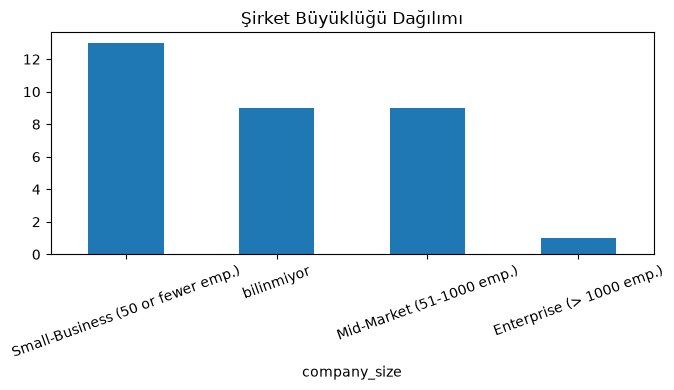

In [16]:
df['company_size'].fillna('bilinmiyor').value_counts().plot.bar(
    figsize=(7,4), title='Şirket Büyüklüğü Dağılımı', rot=20
)
plt.tight_layout()
plt.show()

## 6. Negatif review'ların özetleri

In [17]:
neg = df[df['sentiment'] == 'negatif'][['date','rating','topics','summary']]
print(f'Negatif review sayısı: {len(neg)}')
neg

Negatif review sayısı: 2


,date,rating,topics,summary
21,2025-07-30,5.0,"[UX / kullanım kolaylığı, arama & filtreleme, fiyat]",Apollo.io'nun arama ve niyeti tespit etme özellikleri kullanıcı dostu olsa da kredi sistemi ve düşük lead export lim...
27,2025-07-31,4.5,"[veri kalitesi, email deliverability]","LinkedIn doğrulanmış veri kalitesi prospecting'i kolaylaştırsa da, toplu e-posta gönderimi için kimlik doğrulama sor..."


## 7. Örnek review — ham metin + Claude çıktısı

In [18]:
import json

with open('data/reviews_clean.json', encoding='utf-8') as f:
    raw = {r['reviewId']: r for r in json.load(f)}

for _, row in df.head(3).iterrows():
    r = raw.get(row['review_id'], {})
    print('─' * 60)
    print(f"📅 {row['date']}  ⭐ {row['rating']}  🏢 {row['company_size']}")
    print(f"LIKES   : {str(r.get('likes',''))[:120]}")
    print(f"DISLIKES: {str(r.get('dislikes',''))[:120]}")
    print(f"TOPICS  : {row['topics']}")
    print(f"SENTIMENT: {row['sentiment']}")
    print(f"SUMMARY : {row['summary']}")
    print()

────────────────────────────────────────────────────────────
📅 2025-07-24  ⭐ 5.0  🏢 Small-Business (50 or fewer emp.)
LIKES   : My experience in sales, combined with the quality of leads I generate, enhances the effectiveness of my prospecting, lea
DISLIKES: Credits don’t roll over once they’re used.
TOPICS  : ['veri kalitesi', 'genel olumlu']
SENTIMENT: pozitif
SUMMARY : Apollo.io satış deneyimi ve yüksek kaliteli leads sayesinde başarılı prospecting sonuçları sağlamakla birlikte, kullanılmayan kredilerin devredilmemesi kullanıcıyı hayal kırıklığına uğratıyor.

────────────────────────────────────────────────────────────
📅 2025-07-25  ⭐ 4.5  🏢 Enterprise (> 1000 emp.)
LIKES   : Prospecting and email sequencing, ability to call
DISLIKES: At times calls drop. Specific to certain MEA countries.
TOPICS  : ['otomasyon', 'email deliverability', 'genel olumlu']
SENTIMENT: pozitif
SUMMARY : Apollo.io prospecting ve email sequencing özellikleri ile arama imkanı sunsa da, bazı MEA ülkelerinde ç